In [2]:
emoji_pool = ["😀", "😑", "😥"]
num_samples = 3
output_dir = "/content/drive/MyDrive/MyStickerDataset/"

import requests
import os

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def download_twemoji(emoji, save_path="emoji.png"):
    codepoints = "-".join(f"{ord(c):x}" for c in emoji)
    url = f"https://cdn.jsdelivr.net/gh/twitter/twemoji@14.0.2/assets/72x72/{codepoints}.png"

    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, "wb") as f:
            f.write(response.content)
        print(f"✅ Emoji saved to: {save_path}")
    else:
        print(f"❌ Failed to download emoji {emoji} — {response.status_code}")

for i in range(num_samples):
    emoji_png_path = f"{output_dir}/emojis/emoji_{i:03d}.png"
    download_twemoji(emoji_pool[i], emoji_png_path)
    print(f"[{i}] ✅ Готово: {emoji_pool[i]}")

✅ Emoji saved to: /content/drive/MyDrive/MyStickerDataset//emojis/emoji_000.png
[0] ✅ Готово: 😀
✅ Emoji saved to: /content/drive/MyDrive/MyStickerDataset//emojis/emoji_001.png
[1] ✅ Готово: 😑
✅ Emoji saved to: /content/drive/MyDrive/MyStickerDataset//emojis/emoji_002.png
[2] ✅ Готово: 😥


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_face_encoder(input_shape=(128, 128, 3)):
    """
    Создает кодировщик для черт лица.
    Это сжимающая часть U-Net. Она извлекает ключевые признаки,
    сохраняя выходы промежуточных слоев для skip-connections.
    """
    inputs = layers.Input(shape=input_shape, name='face_input')

    # Сжимающий путь (U-Net Encoder)
    # Блок 1: 128 -> 64
    c1 = layers.Conv2D(64, (4, 4), strides=2, padding='same', activation='relu')(inputs)
    c1 = layers.BatchNormalization()(c1)

    # Блок 2: 64 -> 32
    c2 = layers.Conv2D(128, (4, 4), strides=2, padding='same', activation='relu')(c1)
    c2 = layers.BatchNormalization()(c2)

    # Блок 3: 32 -> 16
    c3 = layers.Conv2D(256, (4, 4), strides=2, padding='same', activation='relu')(c2)
    c3 = layers.BatchNormalization()(c3)

    # Блок 4: 16 -> 8
    c4 = layers.Conv2D(512, (4, 4), strides=2, padding='same', activation='relu')(c3)
    c4 = layers.BatchNormalization()(c4)

    # Блок 5: 8 -> 4
    c5 = layers.Conv2D(512, (4, 4), strides=2, padding='same', activation='relu')(c4)
    c5 = layers.BatchNormalization()(c5)

    model = Model(inputs=inputs, outputs=[c1, c2, c3, c4, c5], name='face_encoder')
    return model

def build_emoji_encoder(input_shape=(64, 64, 3)):
    """
    Создает кодировщик для эмодзи.
    Преобразует изображение эмодзи в компактный вектор признаков.
    """
    inputs = layers.Input(shape=input_shape, name='emoji_input')

    x = layers.Conv2D(64, (4, 4), strides=2, padding='same', activation='relu')(inputs) # 64 -> 32
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (4, 4), strides=2, padding='same', activation='relu')(x) # 32 -> 16
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (4, 4), strides=2, padding='same', activation='relu')(x) # 16 -> 8
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(512, (4, 4), strides=2, padding='same', activation='relu')(x) # 8 -> 4
    x = layers.BatchNormalization()(x)

    # Выход - карта признаков 4x4x512, как и у Face Encoder
    model = Model(inputs=inputs, outputs=x, name='emoji_encoder')
    return model

def StickerGenerator(face_input_shape=(128, 128, 3), emoji_input_shape=(64, 64, 3)):
    """
    Собирает все компоненты в единую модель генерации стикеров.
    """
    # 1. Входные слои
    face_input = layers.Input(shape=face_input_shape, name='face_input')
    emoji_input = layers.Input(shape=emoji_input_shape, name='emoji_input')

    # 2. Кодировщики
    face_encoder = build_face_encoder(face_input_shape)
    emoji_encoder = build_emoji_encoder(emoji_input_shape)

    # Получаем признаки от кодировщиков
    # face_skips - это список выходов промежуточных слоев для U-Net
    *face_skips, face_vec = face_encoder(face_input)
    emoji_vec = emoji_encoder(emoji_input)

    # 3. Bottleneck (бутылочное горлышко)
    # Объединяем векторы от лица и эмодзи
    bottleneck = layers.Concatenate(name='bottleneck')([face_vec, emoji_vec])

    # 4. Декодер (расширяющий путь)
    # Блок 1: 4 -> 8
    d1 = layers.Conv2DTranspose(512, (4, 4), strides=2, padding='same', activation='relu')(bottleneck)
    d1 = layers.BatchNormalization()(d1)
    d1 = layers.Concatenate()([d1, face_skips[3]]) # Skip connection

    # Блок 2: 8 -> 16
    d2 = layers.Conv2DTranspose(256, (4, 4), strides=2, padding='same', activation='relu')(d1)
    d2 = layers.BatchNormalization()(d2)
    d2 = layers.Concatenate()([d2, face_skips[2]]) # Skip connection

    # Блок 3: 16 -> 32
    d3 = layers.Conv2DTranspose(128, (4, 4), strides=2, padding='same', activation='relu')(d2)
    d3 = layers.BatchNormalization()(d3)
    d3 = layers.Concatenate()([d3, face_skips[1]]) # Skip connection

    # Блок 4: 32 -> 64
    d4 = layers.Conv2DTranspose(64, (4, 4), strides=2, padding='same', activation='relu')(d3)
    d4 = layers.BatchNormalization()(d4)
    d4 = layers.Concatenate()([d4, face_skips[0]]) # Skip connection

    # Выходной слой: 64 -> 128
    output_sticker = layers.Conv2DTranspose(
        4, (4, 4), strides=2, padding='same', activation='sigmoid', name='sticker_output'
    )(d4)

    # Собираем итоговую модель
    model = Model(inputs=[face_input, emoji_input], outputs=output_sticker, name='StickerGenerator')

    return model

# --- Пример использования ---

# 1. Создание модели
model = StickerGenerator()
model.summary()

# 2. Компиляция модели
# Для задач image-to-image хорошо подходит комбинация L1 (MAE) и/или SSIM.
# L1 помогает с резкостью, SSIM - со структурным сходством.
# Также можно добавить adversarial loss (GAN), но начнем с простого.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
model.compile(optimizer=optimizer, loss='mae', metrics=['mse'])

Model: "StickerGenerator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ face_input          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ face_encoder        │ [(None, 64, 64,   │  6,957,248 │ face_input[0][0]  │
│ (Functional)        │ 64), (None, 32,   │            │                   │
│                     │ 32, 128), (None,  │            │                   │
│                     │ 16, 16, 256),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 512), (None, 4,   │            │                   │
│                     │ 4, 512)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_encoder       │ (None, 4, 4, 512) │  2,760,384 │ emoji_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck          │ (None, 4, 4,      │          0 │ face_encoder[0][… │
│ (Concatenate)       │ 1024)             │            │ emoji_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 512) │  8,389,120 │ bottleneck[0][0]  │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ batch_normalizat… │
│ (Concatenate)       │ 1024)             │            │ face_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │  4,194,560 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Concatenate)       │ 512)              │            │ face_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │  1,048,704 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Concatenate)       │ 256)              │            │ face_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 64, 64,    │    262,208 │ concatenate_2[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                 

 Total params: 23,624,260 (90.12 MB)

 Trainable params: 23,617,476 (90.09 MB)

 Non-trainable params: 6,784 (26.50 KB)

In [4]:
import tensorflow as tf
import glob
import os
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm # Для красивого прогресс-бара

# ===================================================================
# ЧАСТЬ 1: НОВЫЙ ЗАГРУЗЧИК ДАННЫХ
# ===================================================================

def process_triplet(face_path, emoji_path, sticker_path):
    """Обрабатывает одну тройку (лицо, эмодзи, стикер)."""
    # Загружаем и обрабатываем реальное лицо (JPG)
    face_img = tf.io.read_file(face_path)
    face_img = tf.image.decode_jpeg(face_img, channels=3) # Используем decode_jpeg
    face_img = tf.image.resize(face_img, [128, 128]) / 255.0

    # Загружаем и обрабатываем эмодзи (PNG)
    emoji_img = tf.io.read_file(emoji_path)
    emoji_img = tf.image.decode_png(emoji_img, channels=3)
    emoji_img = tf.image.resize(emoji_img, [64, 64]) / 255.0

    # Загружаем и обрабатываем целевой стикер (PNG)
    sticker_img = tf.io.read_file(sticker_path)
    sticker_img = tf.image.decode_png(sticker_img, channels=4)  # RGBA
    sticker_img = tf.image.resize(sticker_img, [128, 128]) / 255.0

    return (face_img, emoji_img), sticker_img

def create_final_dataset(dataset_root_path, batch_size=8):
    """
    Создает датасет из новой структуры папок.
    """
    print("Собираем тройки данных (лицо, эмодзи, стикер)...")

    # 1. Находим все сгенерированные стикеры
    sticker_paths = sorted(glob.glob(f"{dataset_root_path}/generated_stickers/*.png"))

    # 2. Создаем карту эмоций: имя -> путь к файлу
    emoji_map = {
        "happy": f"{dataset_root_path}/emojis/emoji_000.png",
        "neutral": f"{dataset_root_path}/emojis/emoji_001.png",
        "sad": f"{dataset_root_path}/emojis/emoji_002.png"
    }

    final_face_paths = []
    final_emoji_paths = []
    final_sticker_paths = []

    # 3. Для каждого стикера находим соответствующее ему лицо и эмодзи
    for sticker_path in tqdm(sticker_paths, desc="Parsing dataset"):
        basename = os.path.basename(sticker_path) # Например, "000001_happy.png"
        parts = os.path.splitext(basename)[0].split('_') # -> ["000001", "happy"]

        face_id = parts[0]
        emotion = parts[1]

        # Собираем пути
        face_path = f"{dataset_root_path}/real_faces/{face_id}.jpg"
        emoji_path = emoji_map.get(emotion)

        # Добавляем тройку, только если все файлы существуют
        if os.path.exists(face_path) and emoji_path and os.path.exists(emoji_path):
            final_face_paths.append(face_path)
            final_emoji_paths.append(emoji_path)
            final_sticker_paths.append(sticker_path)

    print(f"Найдено {len(final_face_paths)} корректных наборов данных.")

    # 4. Создаем tf.data.Dataset
    dataset = tf.data.Dataset.from_tensor_slices((final_face_paths, final_emoji_paths, final_sticker_paths))
    dataset = dataset.shuffle(buffer_size=len(final_face_paths), reshuffle_each_iteration=True)
    dataset = dataset.map(process_triplet, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ===================================================================
# ЧАСТЬ 2: ОСНОВНОЙ СКРИПТ ОБУЧЕНИЯ (без изменений, кроме вызова функции)
# ===================================================================

# --- Конфигурация ---
DATASET_PATH = "/content/drive/MyDrive/MyStickerDataset"  # ВАШ ПУТЬ К ДАННЫМ
BATCH_SIZE = 8
EPOCHS = 150
LEARNING_RATE = 0.0002

CHECKPOINT_DIR = "./training_checkpoints"
LOG_DIR = "./logs"
SAMPLES_DIR = "./training_samples"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

# Callback класс остается без изменений (вставьте ваш код для ImageGenerationCallback сюда)
class ImageGenerationCallback(tf.keras.callbacks.Callback):
    """Колбэк для генерации и сохранения примеров стикеров в процессе обучения."""
    def __init__(self, validation_face, validation_emojis, emoji_names, save_dir):
        super().__init__()
        self.validation_face = validation_face
        self.validation_emojis = validation_emojis
        self.emoji_names = emoji_names
        self.save_dir = save_dir

    def on_epoch_end(self, epoch, logs=None):
        # Расширяем face_tensor, чтобы его можно было использовать с батчем эмодзи
        num_emojis = self.validation_emojis.shape[0]
        face_tensor_batch = tf.repeat(self.validation_face, repeats=num_emojis, axis=0)

        # Генерируем стикеры
        predictions = self.model.predict([face_tensor_batch, self.validation_emojis])

        # Сохраняем каждое изображение
        for i, pred_image in enumerate(predictions):
            # Конвертируем тензор в изображение
            pred_image_np = (pred_image * 255).astype(np.uint8)
            img = Image.fromarray(pred_image_np, 'RGBA')

            # Сохраняем
            emoji_name = self.emoji_names[i].replace(".png", "")
            img_path = os.path.join(self.save_dir, f"epoch_{epoch+1:03d}_{emoji_name}.png")
            img.save(img_path)

        print(f"\n✅ Сохранены примеры стикеров для эпохи {epoch+1} в {self.save_dir}")

# --- Основной скрипт ---
if __name__ == '__main__':
    # 1. Загрузка и подготовка данных с помощью НОВОЙ функции
    print(" Cоздание датасета...")
    full_dataset = create_final_dataset(DATASET_PATH, batch_size=BATCH_SIZE)
    print("✅ Датасет готов.")

    # 2. Подготовка данных для колбэка
    # Этот блок тоже нужно адаптировать
    print(" Подготовка данных для колбэка...")
    # Возьмем первое попавшееся реальное лицо
    sample_face_path = sorted(glob.glob(f"{DATASET_PATH}/real_faces/*.jpg"))[0]
    emoji_paths = sorted(glob.glob(f"{DATASET_PATH}/emojis/*.png"))
    emoji_names = [os.path.basename(p) for p in emoji_paths]

    val_face = tf.io.read_file(sample_face_path)
    val_face = tf.image.decode_jpeg(val_face, channels=3) # decode_jpeg
    val_face = tf.image.resize(val_face, [128, 128]) / 255.0
    val_face = tf.expand_dims(val_face, axis=0)

    val_emojis = []
    for path in emoji_paths:
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [64, 64]) / 255.0
        val_emojis.append(img)
    val_emojis = tf.stack(val_emojis, axis=0)
    print("✅ Данные для колбэка готовы.")

    # 3. Создание и компиляция модели (вставьте ваш код для StickerGenerator сюда)
    print(" Cборка модели...")
    model = StickerGenerator()
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=0.5)
    model.compile(optimizer=optimizer, loss='mae', metrics=['mse'])
    model.summary()
    print("✅ Модель собрана и скомпилирована.")

    # 4. Настройка колбэков
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, "sticker_gen_epoch_{epoch:02d}.keras"),
        save_weights_only=False, save_best_only=True, monitor='loss', mode='min', verbose=1
    )
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR)
    image_gen_callback = ImageGenerationCallback(
        validation_face=val_face, validation_emojis=val_emojis,
        emoji_names=emoji_names, save_dir=SAMPLES_DIR
    )

    # 5. Запуск обучения
    print("\n" + "="*50)
    print("🚀 НАЧИНАЕМ ОБУЧЕНИЕ!")
    print("="*50 + "\n")

    model.fit(
        full_dataset,
        epochs=EPOCHS,
        callbacks=[checkpoint_callback, tensorboard_callback, image_gen_callback]
    )

    print("\n" + "="*50)
    print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
    print("="*50 + "\n")
    model.save("/content/drive/MyDrive/MyStickerDataset/final_sticker_generator.keras")

 Cоздание датасета...
Собираем тройки данных (лицо, эмодзи, стикер)...


Parsing dataset:   0%|          | 0/300 [00:00<?, ?it/s]

Найдено 300 корректных наборов данных.
✅ Датасет готов.
 Подготовка данных для колбэка...
✅ Данные для колбэка готовы.
 Cборка модели...


Model: "StickerGenerator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ face_input          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ face_encoder        │ [(None, 64, 64,   │  6,957,248 │ face_input[0][0]  │
│ (Functional)        │ 64), (None, 32,   │            │                   │
│                     │ 32, 128), (None,  │            │                   │
│                     │ 16, 16, 256),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 512), (None, 4,   │            │                   │
│                     │ 4, 512)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_encoder       │ (None, 4, 4, 512) │  2,760,384 │ emoji_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck          │ (None, 4, 4,      │          0 │ face_encoder[0][… │
│ (Concatenate)       │ 1024)             │            │ emoji_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 8, 8, 512) │  8,389,120 │ bottleneck[0][0]  │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 8, 8,      │          0 │ batch_normalizat… │
│ (Concatenate)       │ 1024)             │            │ face_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 16, 16,    │  4,194,560 │ concatenate_8[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Concatenate)       │ 512)              │            │ face_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_10 │ (None, 32, 32,    │  1,048,704 │ concatenate_9[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Concatenate)       │ 256)              │            │ face_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_11 │ (None, 64, 64,    │    262,208 │ concatenate_10[0… │
│ (Conv2DTranspose)   │ 64)               │            │                 

 Total params: 23,624,260 (90.12 MB)

 Trainable params: 23,617,476 (90.09 MB)

 Non-trainable params: 6,784 (26.50 KB)

✅ Модель собрана и скомпилирована.

🚀 НАЧИНАЕМ ОБУЧЕНИЕ!

Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3856 - mse: 0.1880
Epoch 1: loss improved from inf to 0.35157, saving model to ./training_checkpoints/sticker_gen_epoch_01.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step

✅ Сохранены примеры стикеров для эпохи 1 в ./training_samples
38/38 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - loss: 0.3847 - mse: 0.1876
Epoch 2/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2749 - mse: 0.1459
Epoch 2: loss improved from 0.35157 to 0.26017, saving model to ./training_checkpoints/sticker_gen_epoch_02.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step

✅ Сохранены примеры стикеров для эпохи 2 в ./training_samples
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 0.2745 - mse: 0.1457
Epoch 3/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2225 - mse: 0.1233
Epoch 3: loss improved from 0.26017 to 0.21216, saving model to ./training_checkpoints/sticker_gen_epoch_03.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=None.

In [5]:
model.save("/content/drive/MyDrive/MyStickerDataset/final_sticker_generator.keras")

Loading model from /content/drive/MyDrive/MyStickerDataset/final_sticker_generator.keras...
✅ Model loaded successfully.
Found 2 faces to test.
Found 3 emojis to use.
------------------------------------------------------------
Processing face: face_000.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
  > Generated sticker for 'emoji_000' emoji, saved to /content/drive/MyDrive/MyStickerDataset/test_outputs/face_000_as_emoji_000.png


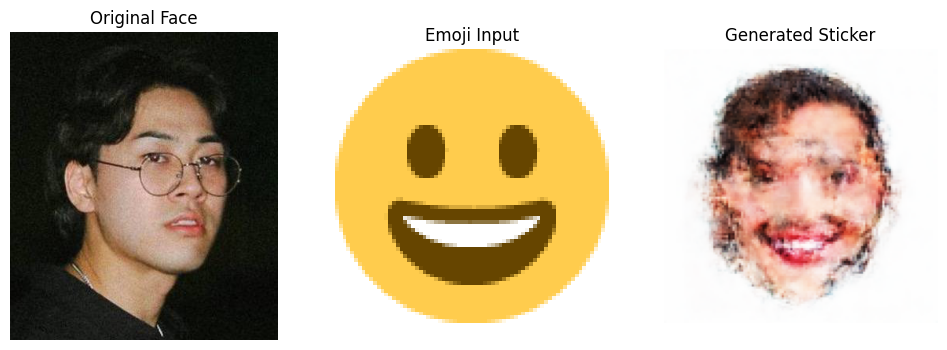

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
  > Generated sticker for 'emoji_001' emoji, saved to /content/drive/MyDrive/MyStickerDataset/test_outputs/face_000_as_emoji_001.png


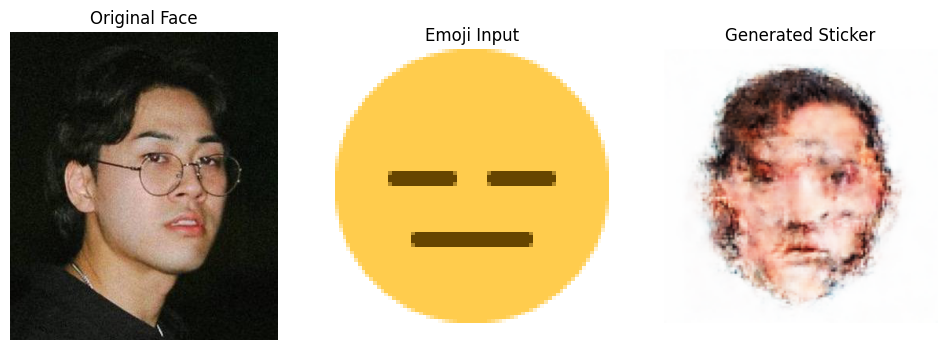

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
  > Generated sticker for 'emoji_002' emoji, saved to /content/drive/MyDrive/MyStickerDataset/test_outputs/face_000_as_emoji_002.png


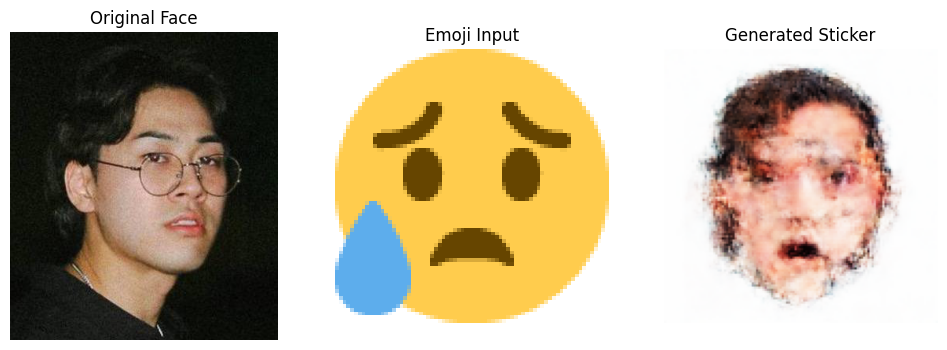

------------------------------------------------------------
Processing face: photo_2025-06-19_00-04-20.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
  > Generated sticker for 'emoji_000' emoji, saved to /content/drive/MyDrive/MyStickerDataset/test_outputs/photo_2025-06-19_00-04-20_as_emoji_000.png


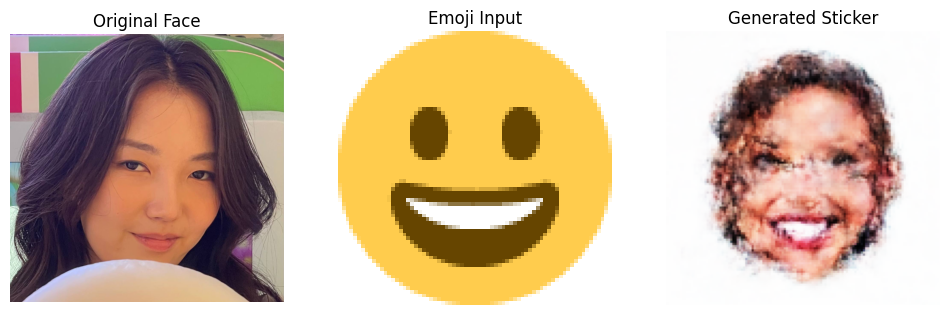

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
  > Generated sticker for 'emoji_001' emoji, saved to /content/drive/MyDrive/MyStickerDataset/test_outputs/photo_2025-06-19_00-04-20_as_emoji_001.png


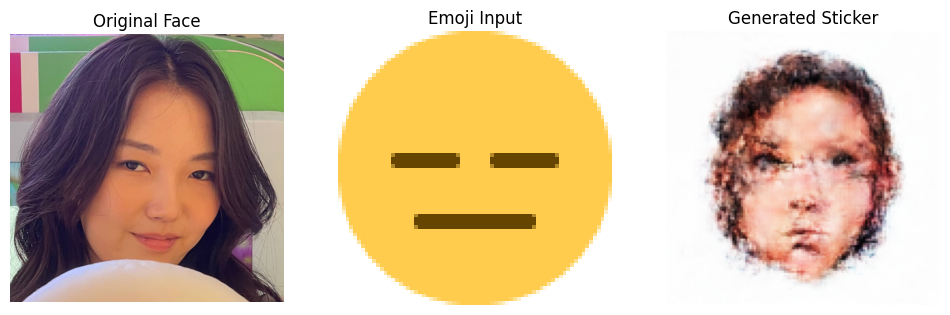

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
  > Generated sticker for 'emoji_002' emoji, saved to /content/drive/MyDrive/MyStickerDataset/test_outputs/photo_2025-06-19_00-04-20_as_emoji_002.png


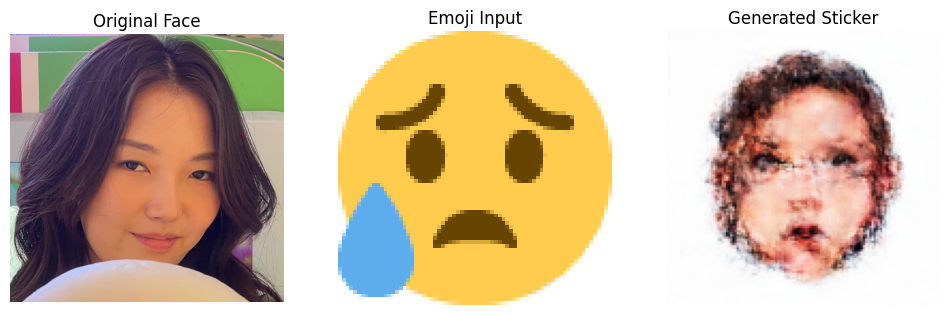


✅ All test images processed successfully!
Check the '/content/drive/MyDrive/MyStickerDataset/test_outputs/' folder for all generated stickers.


In [6]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt

# =================================================================
# ШАГ 1: КОНФИГУРАЦИЯ
# =================================================================

# --- Укажите ваши пути здесь ---
GDRIVE_PATH = "/content/drive/MyDrive/MyStickerDataset/"
MODEL_PATH = GDRIVE_PATH + "final_sticker_generator.keras"
TEST_FACES_DIR = GDRIVE_PATH + "test_faces/"      # Папка с лицами для тестирования
EMOJIS_DIR = GDRIVE_PATH + "emojis/"              # Папка с вашими 3 эмодзи
OUTPUT_DIR = GDRIVE_PATH + "test_outputs/"        # Папка для сохранения результатов

# Создаем выходную директорию, если ее нет
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =================================================================
# ШАГ 2: ФУНКЦИИ ПРЕДОБРАБОТКИ (без изменений)
# =================================================================

def preprocess_face(image_path):
    """Prepares a face image for the model."""
    img_bytes = tf.io.read_file(image_path)
    # Use decode_image to handle both PNG and JPG
    img = tf.image.decode_image(img_bytes, channels=3)
    img = tf.image.resize(img, [128, 128]) / 255.0
    img = tf.expand_dims(img, axis=0)  # Add batch dimension
    return img

def preprocess_emoji(image_path):
    """Prepares an emoji image for the model."""
    img_bytes = tf.io.read_file(image_path)
    img = tf.image.decode_png(img_bytes, channels=3)
    img = tf.image.resize(img, [64, 64]) / 255.0
    img = tf.expand_dims(img, axis=0)  # Add batch dimension
    return img


# =================================================================
# ШАГ 3: ЗАГРУЗКА МОДЕЛИ И ФАЙЛОВ
# =================================================================

print(f"Loading model from {MODEL_PATH}...")
try:
    # Load the model, providing the custom loss if you used one during training
    # If you didn't use a custom loss, you can remove the `custom_objects` part.
    # For now, we assume no custom objects for simplicity.
    trained_model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

# Get lists of all face and emoji files
face_paths = sorted(glob.glob(os.path.join(TEST_FACES_DIR, '*.*')))
emoji_paths = sorted(glob.glob(os.path.join(EMOJIS_DIR, '*.png')))

if not face_paths or not emoji_paths:
    print("❌ Error: Test faces or emoji folders are empty. Please check the paths.")
    exit()

print(f"Found {len(face_paths)} faces to test.")
print(f"Found {len(emoji_paths)} emojis to use.")


# =================================================================
# ШАГ 4: ОСНОВНОЙ ЦИКЛ ГЕНЕРАЦИИ И ОТОБРАЖЕНИЯ
# =================================================================

# Loop through every face in the test folder
for face_path in face_paths:
    print("-" * 60)
    print(f"Processing face: {os.path.basename(face_path)}")

    # Load the original face image for display
    face_for_display = Image.open(face_path)

    # Loop through every emoji for the current face
    for emoji_path in emoji_paths:
        # --- Prediction ---
        face_tensor = preprocess_face(face_path)
        emoji_tensor = preprocess_emoji(emoji_path)
        generated_tensor = trained_model.predict([face_tensor, emoji_tensor])

        # --- Post-processing ---
        # Remove batch dimension, convert to 0-255 uint8 format
        output_sticker_np = (generated_tensor[0] * 255).astype(np.uint8)

        # --- Saving ---
        face_name = os.path.splitext(os.path.basename(face_path))[0]
        emoji_name = os.path.splitext(os.path.basename(emoji_path))[0]
        output_filename = f"{face_name}_as_{emoji_name}.png"
        save_path = os.path.join(OUTPUT_DIR, output_filename)

        # Use PIL to save the NumPy array as a PNG
        Image.fromarray(output_sticker_np, 'RGBA').save(save_path)
        print(f"  > Generated sticker for '{emoji_name}' emoji, saved to {save_path}")

        # --- Displaying ---
        emoji_for_display = Image.open(emoji_path)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(face_for_display)
        plt.title("Original Face")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(emoji_for_display)
        plt.title("Emoji Input")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(output_sticker_np)
        plt.title("Generated Sticker")
        plt.axis("off")

        plt.show()

print("\n" + "="*60)
print("✅ All test images processed successfully!")
print(f"Check the '{OUTPUT_DIR}' folder for all generated stickers.")